# Heston PDE — Numerical Evaluation

**Course:** Partial Differential Equations with Applications in Physics and Industry  
**Authors:** Oliwier Arent, Filip Miśkiewicz, Natalia Przewdzięk

This notebook implements the computational pipeline for the project. Full mathematical derivations and extended interpretations are given in the accompanying LaTeX report (`main.tex` on Overleaf).

In [79]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

%matplotlib inline

# Project root on the Python path (notebook may be run from any working directory).
ROOT = Path.cwd()
if not (ROOT / "utils").exists() and (ROOT.parent / "utils").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

from utils.reproducibility import set_project_seed

set_project_seed()

from utils.black_scholes import (
    black_scholes_call,
    black_scholes_put,
    implied_volatility,
    put_call_parity_check,
)
from utils.heston_analytical import (
    black_scholes_limit_error,
    heston_call_price,
    heston_put_price,
)
from utils.grid_builder import (
    build_heston_grid,
    build_operators_with_boundary_conditions,
    mesh_spacing_stats,
)

FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

## 1. Black-Scholes baseline

We implement the analytical Black-Scholes pricer and implied-volatility inversion. This section establishes the reference model used throughout the project. The governing PDE is

$$
\frac{\partial V}{\partial t}
+ rS\frac{\partial V}{\partial S}
+ \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
- rV = 0.
$$

The full derivation and boundary conditions are given in Section 2 of the PDF report.

In [80]:
# Standard test parameters (same notation as in the report).
S0 = 100.0   # spot
K = 100.0    # strike (ATM)
T = 1.0      # maturity [years]
r = 0.05     # risk-free rate
sigma = 0.20 # constant volatility

call_price = black_scholes_call(S0, K, T, r, sigma)
put_price = black_scholes_put(S0, K, T, r, sigma)

print(f"ATM call price: {call_price:.4f}")
print(f"ATM put price:  {put_price:.4f}")
print(f"Put-call parity holds: {put_call_parity_check(call_price, put_price, S0, K, T, r)}")

ATM call price: 10.4506
ATM put price:  5.5735
Put-call parity holds: True


### Price curves vs. strike

Short sanity check: call (put) value decreases (increases) with strike at fixed maturity.

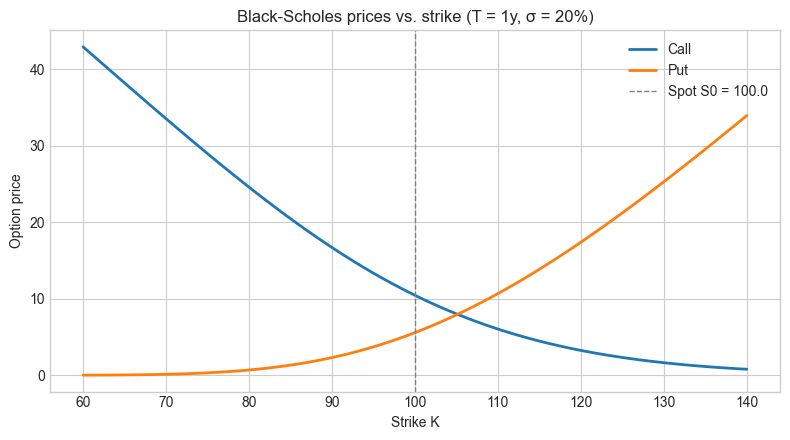

In [81]:
strikes = np.linspace(60, 140, 81)
call_curve = [black_scholes_call(S0, k, T, r, sigma) for k in strikes]
put_curve = [black_scholes_put(S0, k, T, r, sigma) for k in strikes]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(strikes, call_curve, label="Call", color="tab:blue", lw=2)
ax.plot(strikes, put_curve, label="Put", color="tab:orange", lw=2)
ax.axvline(S0, color="gray", ls="--", lw=1, label=f"Spot S0 = {S0}")
ax.set_xlabel("Strike K")
ax.set_ylabel("Option price")
ax.set_title("Black-Scholes prices vs. strike (T = 1y, σ = 20%)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "bs_price_curves.png", dpi=150)
display(fig)
plt.close(fig)

### Implied volatility inversion

Given a market call price, Newton-Raphson on the Black-Scholes formula recovers the implied volatility $\sigma_{\mathrm{imp}}$ such that

$$
C_{\mathrm{BS}}(S, K, T, r, \sigma_{\mathrm{imp}}) = C_{\mathrm{market}}.
$$

This routine is reused later when comparing model-generated and market volatility smiles.

In [82]:
# Perturb the model price slightly to mimic a market quote.
market_call = call_price * 1.02
sigma_imp = implied_volatility(market_call, S0, K, T, r, option_type="call")

print(f"Model call (σ = {sigma:.0%}): {call_price:.4f}")
print(f"Perturbed market call:      {market_call:.4f}")
print(f"Recovered implied vol:      {sigma_imp:.4%}")
print(f"Round-trip price error:     {black_scholes_call(S0, K, T, r, sigma_imp) - market_call:.2e}")

Model call (σ = 20%): 10.4506
Perturbed market call:      10.6596
Recovered implied vol:      20.5566%
Round-trip price error:     6.86e-11


## 2. Heston model formulation

The Heston model extends Black-Scholes by replacing constant volatility with a stochastic variance process. Under the risk-neutral measure $\mathbb{Q}$,

$$
\mathrm{d}S_t = r S_t\,\mathrm{d}t + \sqrt{v_t}\,S_t\,\mathrm{d}W_t^{(1)},
$$

$$
\mathrm{d}v_t = \kappa(\theta - v_t)\,\mathrm{d}t + \xi\sqrt{v_t}\,\mathrm{d}W_t^{(2)},
\qquad
\mathrm{d}W_t^{(1)}\,\mathrm{d}W_t^{(2)} = \rho\,\mathrm{d}t.
$$

Applying Itô's lemma yields the two-dimensional pricing PDE (see Section 3 of the PDF report for the full derivation, boundary conditions, and the log-price transformation $x = \ln(S/K)$):

$$
\frac{\partial V}{\partial t}
+ rS\frac{\partial V}{\partial S}
+ \kappa(\theta - v)\frac{\partial V}{\partial v}
+ \frac{1}{2}vS^2\frac{\partial^2 V}{\partial S^2}
+ \rho\xi v S\frac{\partial^2 V}{\partial S\,\partial v}
+ \frac{1}{2}\xi^2 v\frac{\partial^2 V}{\partial v^2}
- rV = 0.
$$

No new code is required in this section; the numerical solver built on this formulation follows in later notebook sections.

## 3. Semi-analytical Heston benchmark

Unlike Black-Scholes, the Heston model has no elementary closed-form price. However, the affine structure yields a characteristic function $\varphi(u)$ of log-spot, and European calls can be recovered by Fourier inversion (Lewis, 2001):

$$
C = e^{-rT}\left(F - \frac{\sqrt{FK}}{\pi}\int_0^\infty \mathrm{Re}\!\left[e^{-iu\ln(F/K)}\,\frac{\varphi(u-i/2)}{u^2 + 1/4}\right]\mathrm{d}u\right),
\qquad F = S_0 e^{rT}.
$$

We use the numerically stable characteristic-function formulation of Albrecher et al. (2007). This benchmark provides an exact reference for the ADI PDE solver convergence study. Details are in Section 4 of the PDF report.

In [83]:
# Reference Heston parameters (Feller condition satisfied: 2*kappa*theta > xi^2).
HESTON = dict(v0=0.04, kappa=2.0, theta=0.04, xi=0.3, rho=-0.7)
S0, r, T = 100.0, 0.05, 1.0
sigma_bs = HESTON["theta"] ** 0.5  # sqrt(theta) ~ 20% vol

atm_call = heston_call_price(S0, S0, T, r, **HESTON)
atm_bs = black_scholes_call(S0, S0, T, r, sigma_bs)

atm_put = heston_put_price(S0, S0, T, r, **HESTON)
parity_lhs = atm_call - atm_put
parity_rhs = S0 - S0 * np.exp(-r * T)

print(f"Heston ATM call:   {atm_call:.4f}")
print(f"Black-Scholes ATM: {atm_bs:.4f}")
print(f"Put-call parity residual: {abs(parity_lhs - parity_rhs):.2e}")

Heston ATM call:   10.3942
Black-Scholes ATM: 10.4506
Put-call parity residual: 5.33e-15


### Price skew: Heston vs. Black-Scholes

With $\rho < 0$, stochastic volatility generates a leverage effect: out-of-the-money puts become relatively more expensive than the constant-volatility benchmark.

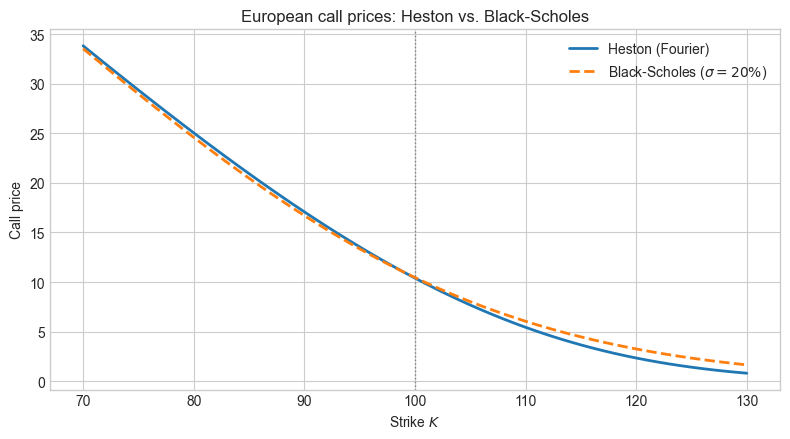

In [84]:
strikes = np.linspace(70, 130, 61)
heston_calls = [heston_call_price(S0, k, T, r, **HESTON) for k in strikes]
bs_calls = [black_scholes_call(S0, k, T, r, sigma_bs) for k in strikes]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(strikes, heston_calls, label="Heston (Fourier)", color="tab:blue", lw=2)
ax.plot(strikes, bs_calls, label=fr"Black-Scholes ($\sigma={sigma_bs * 100:.0f}\%$)", color="tab:orange", lw=2, ls="--")
ax.axvline(S0, color="gray", ls=":", lw=1)
ax.set_xlabel("Strike $K$")
ax.set_ylabel("Call price")
ax.set_title("European call prices: Heston vs. Black-Scholes")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "heston_vs_bs_strikes.png", dpi=150)
display(fig)
plt.close(fig)

### Black-Scholes limiting case ($\xi \to 0$)

Setting $v_0 = \theta = \sigma^2$ and $\rho = 0$, the Heston price should converge to the Black-Scholes value as $\xi \to 0$.

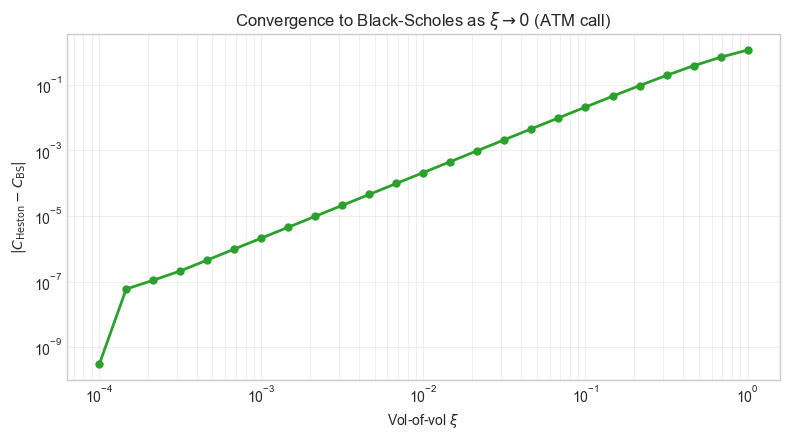

Smallest error: 2.98e-10 at xi = 1.0e-04


In [85]:
xi_grid, errors = black_scholes_limit_error(S0, S0, T, r, sigma_bs, kappa=HESTON["kappa"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(xi_grid, errors, "o-", color="tab:green", lw=2, ms=5)
ax.set_xlabel(r"Vol-of-vol $\xi$")
ax.set_ylabel(r"$|C_{\mathrm{Heston}} - C_{\mathrm{BS}}|$")
ax.set_title("Convergence to Black-Scholes as $\\xi \\to 0$ (ATM call)")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "heston_bs_limit.png", dpi=150)
display(fig)
plt.close(fig)

print(f"Smallest error: {errors.min():.2e} at xi = {xi_grid[errors.argmin()]:.1e}")

## 4. Spatial grid and finite-difference operators

The Heston PDE is solved on a transformed domain in log-moneyness $x = \ln(S/K)$ and variance $v$. A uniform tensor-product grid would waste nodes away from the at-the-money strip and from the degenerate boundary $v=0$. We therefore use sinh stretching,

$$
x(\xi) = x_{\mathrm{mid}} + \frac{L}{2}\,\frac{\sinh(\mu_x \xi)}{\sinh(\mu_x)}, \qquad \xi \in [-1,1],
$$

$$
v(\eta) = v_{\max}\,\frac{\sinh(\mu_v \eta)}{\sinh(\mu_v)}, \qquad \eta \in [0,1].
$$

Non-uniform spacing enters one-dimensional finite-difference stencils for $\partial_x$, $\partial_{xx}$, $\partial_v$, and $\partial_{vv}$. Full motivation and boundary design are in the PDF report (to be updated after this run).

In [86]:
# Grid parameters for the ADI solver (refined in the convergence study).
GRID_NX = 81
GRID_NV = 41
X_MIN, X_MAX = -2.0, 2.0
V_MAX = 0.5
MU_X = 3.0
MU_V = 4.0

grid = build_heston_grid(
    nx=GRID_NX,
    nv=GRID_NV,
    x_min=X_MIN,
    x_max=X_MAX,
    v_max=V_MAX,
    concentration_x=MU_X,
    concentration_v=MU_V,
)

x_stats = mesh_spacing_stats(grid.dx_forward)
v_stats = mesh_spacing_stats(grid.dv_forward)

print(f"Grid size: {grid.nx} x {grid.nv} = {grid.nx * grid.nv:,} nodes")
print(f"x spacing: min={x_stats['min']:.4f}, max={x_stats['max']:.4f}, ratio={x_stats['ratio']:.2f}")
print(f"v spacing: min={v_stats['min']:.4f}, max={v_stats['max']:.4f}, ratio={v_stats['ratio']:.2f}")

Grid size: 81 x 41 = 3,321 nodes
x spacing: min=0.0150, max=0.1453, ratio=9.69
v spacing: min=0.0018, max=0.0476, ratio=25.94


### Grid spacing

Smaller $\Delta x$ and $\Delta v$ near $x=0$ and $v=0$ confirm the sinh clustering.

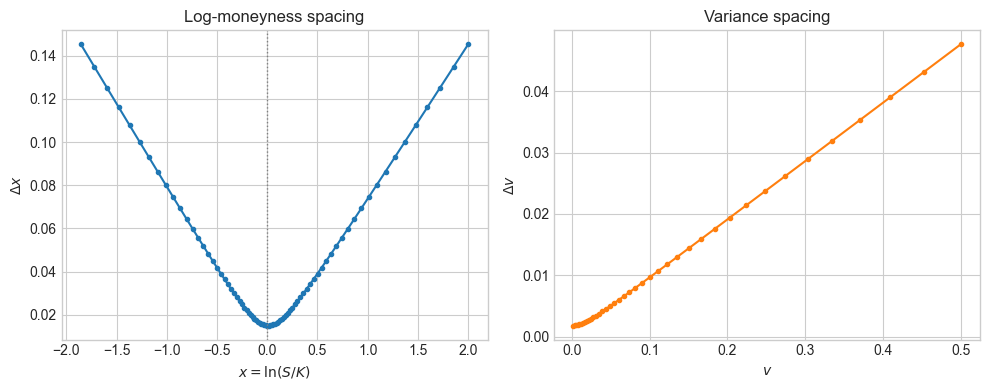

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(grid.x[1:], grid.dx_forward, "o-", ms=3, lw=1.5)
axes[0].axvline(0.0, color="gray", ls=":", lw=1)
axes[0].set_xlabel(r"$x = \ln(S/K)$")
axes[0].set_ylabel(r"$\Delta x$")
axes[0].set_title("Log-moneyness spacing")

axes[1].plot(grid.v[1:], grid.dv_forward, "o-", ms=3, lw=1.5, color="tab:orange")
axes[1].set_xlabel(r"$v$")
axes[1].set_ylabel(r"$\Delta v$")
axes[1].set_title("Variance spacing")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "grid_spacing.png", dpi=150)
display(fig)
plt.close(fig)

### Two-dimensional node layout

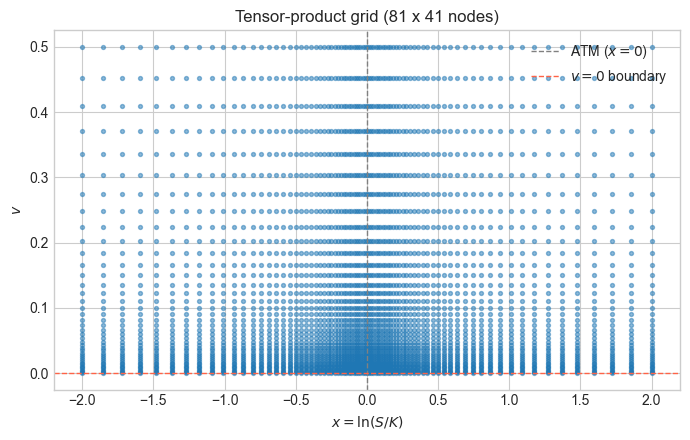

In [88]:
X_mesh, V_mesh = np.meshgrid(grid.x, grid.v, indexing="ij")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(X_mesh.ravel(), V_mesh.ravel(), s=8, alpha=0.5, c="tab:blue")
ax.axvline(0.0, color="gray", ls="--", lw=1, label="ATM ($x=0$)")
ax.axhline(0.0, color="tomato", ls="--", lw=1, label=r"$v=0$ boundary")
ax.set_xlabel(r"$x = \ln(S/K)$")
ax.set_ylabel(r"$v$")
ax.set_title(f"Tensor-product grid ({grid.nx} x {grid.nv} nodes)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "grid_nodes_2d.png", dpi=150)
display(fig)
plt.close(fig)

### Finite-difference operators and boundary rows

European call: Dirichlet treatment in $x$ (values set by payoff/BC in the solver). Degenerate boundary $v=0$: Neumann $\partial u/\partial v = 0$.

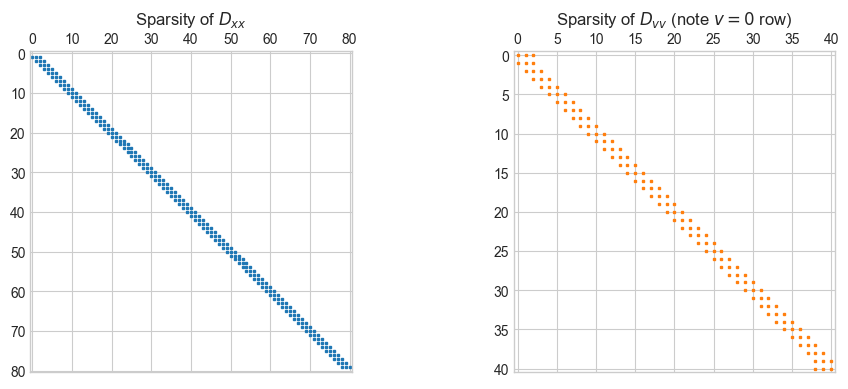

D_xx interior diagonal (sample): -8854.1594
D_v row 0 (v=0 Neumann): [-817.33461029 1089.77948039 -272.4448701     0.        ]
D_vv row 0 (v=0): [ 295426.46528679 -587925.50190281  292499.03661602       0.        ]


In [89]:
ops = build_operators_with_boundary_conditions(grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].spy(ops.D_xx, markersize=1.5, color="tab:blue")
axes[0].set_title(r"Sparsity of $D_{xx}$")
axes[1].spy(ops.D_vv, markersize=1.5, color="tab:orange")
axes[1].set_title(r"Sparsity of $D_{vv}$ (note $v=0$ row)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd_operator_sparsity.png", dpi=150)
display(fig)
plt.close(fig)

# Sanity check: row sums of interior second-derivative stencil should be ~0 (constant functions).
interior_rows = ops.D_xx.diagonal()[1:-1]
print(f"D_xx interior diagonal (sample): {interior_rows[grid.nx//2]:.4f}")
print(f"D_v row 0 (v=0 Neumann): {ops.D_v.getrow(0).toarray().flatten()[:4]}")
print(f"D_vv row 0 (v=0): {ops.D_vv.getrow(0).toarray().flatten()[:4]}")

## 5. ADI numerical solver

We now solve the two-dimensional Heston PDE numerically with an Alternating Direction Implicit (ADI) scheme of Hundsdorfer-Verwer (Douglas) type. Working in reversed time $\tau = T - t$, the terminal payoff becomes an initial condition and the equation is marched forward with operator splitting:

- the mixed derivative term $\rho\xi v\,\partial^2 u/\partial x\partial v$ is treated **explicitly** in a predictor step;
- the $x$- and $v$-directions are then corrected **implicitly**, each requiring only tridiagonal solves via `scipy.linalg.solve_banded`.

A few initial fully implicit (Rannacher) steps damp the non-smooth payoff kink. The solver is validated against the Fourier benchmark of Section 3; the scheme, stability discussion, and numerical results are reported in Section 6 of the PDF report.

In [90]:
import time

from utils.heston_adi_solver import (
    HestonModelParams,
    solve_heston_adi,
    price_at_point,
    prices_along_strikes,
)
from utils.heston_analytical import heston_call_price

# Baseline Heston parameter set (same as Section 3).
S0 = 100.0
K = 100.0
T = 1.0
r = 0.05
v0 = 0.04
kappa = 2.0
theta = 0.04
xi = 0.3
rho = -0.7

# Solver discretisation (baseline grid from Section 4).
N_STEPS = 400
RANNACHER = 10

adi_params = HestonModelParams(r=r, kappa=kappa, theta=theta, xi=xi, rho=rho, K=K)
adi_grid = build_heston_grid(81, 41)

t_start = time.perf_counter()
u_grid, adi_grid, tau_grid = solve_heston_adi(
    adi_params, T, grid=adi_grid, n_steps=N_STEPS, theta=0.5, rannacher_steps=RANNACHER
)
elapsed = time.perf_counter() - t_start

# At-the-money comparison versus the Fourier benchmark.
adi_atm = price_at_point(u_grid, adi_grid, np.log(S0 / K), v0)
fourier_atm = heston_call_price(S0, K, T, r, v0, kappa, theta, xi, rho)
rel_err = abs(adi_atm - fourier_atm) / fourier_atm

print(f"Grid: {adi_grid.nx} x {adi_grid.nv}, time steps: {N_STEPS} (Rannacher {RANNACHER})")
print(f"Solve time: {elapsed:.1f} s")
print(f"ATM ADI price:     {adi_atm:.4f}")
print(f"ATM Fourier price: {fourier_atm:.4f}")
print(f"Relative error:    {rel_err:.3e}")
print(f"Solution min/max:  {u_grid.min():.4f} / {u_grid.max():.4f}")

Grid: 81 x 41, time steps: 400 (Rannacher 10)
Solve time: 37.3 s
ATM ADI price:     10.5077
ATM Fourier price: 10.3942
Relative error:    1.091e-02
Solution min/max:  -0.0000 / 655.0663


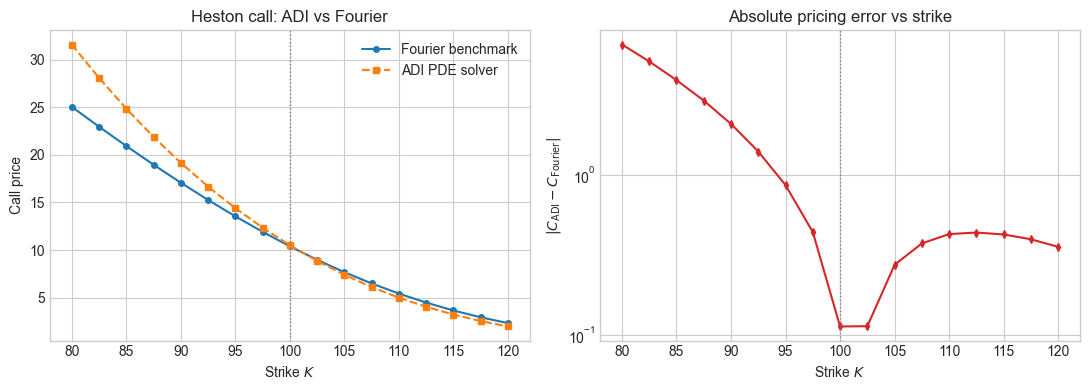

Max abs error over strikes [80,120]: 6.5400e+00
Mean abs error over strikes:         1.5430e+00


In [91]:
# Compare ADI and Fourier call prices across strikes (single solve, interpolated).
strikes = np.linspace(80.0, 120.0, 17)
adi_strike_prices = prices_along_strikes(u_grid, adi_grid, strikes, v0, S0)
fourier_strike_prices = np.array(
    [heston_call_price(S0, Ki, T, r, v0, kappa, theta, xi, rho) for Ki in strikes]
)
abs_err_strikes = np.abs(adi_strike_prices - fourier_strike_prices)

fig, (ax_price, ax_err) = plt.subplots(1, 2, figsize=(11, 4))

ax_price.plot(strikes, fourier_strike_prices, "o-", label="Fourier benchmark", ms=4)
ax_price.plot(strikes, adi_strike_prices, "s--", label="ADI PDE solver", ms=4)
ax_price.axvline(S0, color="gray", ls=":", lw=1)
ax_price.set_xlabel("Strike $K$")
ax_price.set_ylabel("Call price")
ax_price.set_title("Heston call: ADI vs Fourier")
ax_price.legend()

ax_err.semilogy(strikes, abs_err_strikes, "d-", color="tab:red", ms=4)
ax_err.axvline(S0, color="gray", ls=":", lw=1)
ax_err.set_xlabel("Strike $K$")
ax_err.set_ylabel(r"$|C_{\mathrm{ADI}} - C_{\mathrm{Fourier}}|$")
ax_err.set_title("Absolute pricing error vs strike")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "adi_vs_fourier_strikes.png", dpi=150)
display(fig)
plt.close(fig)

print(f"Max abs error over strikes [80,120]: {abs_err_strikes.max():.4e}")
print(f"Mean abs error over strikes:         {abs_err_strikes.mean():.4e}")

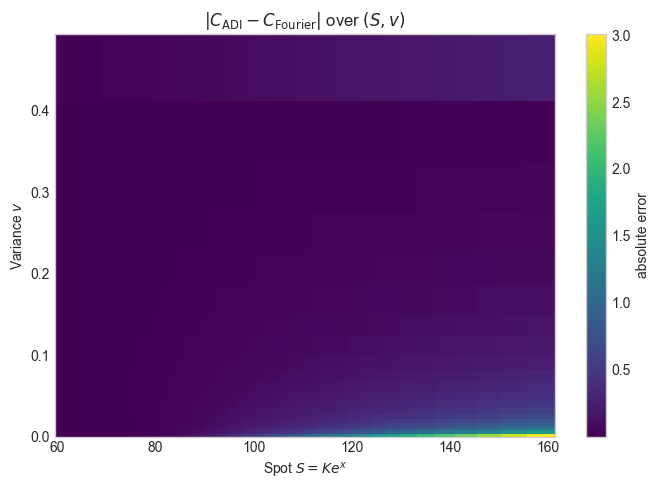

Max abs error on (S,v) window: 3.0058e+00
Mean abs error on (S,v) window:  1.6594e-01


In [92]:
# Spatial error map: |ADI - Fourier| over a region of interest in (S, v).
# Restrict to a financially relevant window to keep Fourier evaluations cheap.
x_mask = (adi_grid.x >= np.log(0.6)) & (adi_grid.x <= np.log(1.6))
v_idx = np.arange(1, adi_grid.nv, 2)  # skip v=0 boundary, subsample variance nodes

x_sel = adi_grid.x[x_mask]
v_sel = adi_grid.v[v_idx]
S_sel = K * np.exp(x_sel)

error_map = np.zeros((x_sel.size, v_sel.size))
for a, xi_node in enumerate(np.where(x_mask)[0]):
    for b, vj in enumerate(v_idx):
        fourier_val = heston_call_price(
            K * np.exp(adi_grid.x[xi_node]), K, T, r, adi_grid.v[vj],
            kappa, theta, xi, rho,
        )
        error_map[a, b] = abs(u_grid[xi_node, vj] - fourier_val)

fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(S_sel, v_sel, error_map.T, shading="auto", cmap="viridis")
ax.set_xlabel("Spot $S = K e^{x}$")
ax.set_ylabel("Variance $v$")
ax.set_title(r"$|C_{\mathrm{ADI}} - C_{\mathrm{Fourier}}|$ over $(S, v)$")
fig.colorbar(mesh, ax=ax, label="absolute error")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "adi_error_heatmap.png", dpi=150)
display(fig)
plt.close(fig)

print(f"Max abs error on (S,v) window: {error_map.max():.4e}")
print(f"Mean abs error on (S,v) window:  {error_map.mean():.4e}")

## 6. Market data pipeline and calibration

We load SPY out-of-the-money call quotes from a frozen CSV snapshot (`data/spy_options_snapshot.csv`, trade date 2026-06-09) so results are reproducible without live API access. After liquidity filters we calibrate:

1. a **flat Black--Scholes** volatility $\sigma_{\mathrm{BS}}$ (single parameter); and  
2. the **Heston** parameters $(v_0, \kappa, \theta, \xi, \rho)$ via Nelder--Mead on the Fourier RMSE.

The calibrated parameters become the market-facing inputs for the ADI solver and implied-volatility analysis. Theory and notation are in **Section 7** of the PDF report; convergence studies follow in notebook §7 / report Section 8.

In [93]:
from utils.calibration import (
    calibrate_black_scholes,
    calibrate_heston,
    heston_model_prices,
)
from utils.market_data import load_snapshot_csv
from utils.black_scholes import black_scholes_call
from utils.heston_adi_solver import HestonModelParams, prices_along_strikes, solve_heston_adi

chain = load_snapshot_csv()

print("=== Market data summary ===")
print(f"Trade date: {chain.trade_date}  |  Expiry: {chain.expiry}")
print(f"Spot S0 = {chain.spot:.2f}  |  T = {chain.maturity:.4f} y  |  r = {chain.rate:.4f}")
print(f"Quotes after filtering: {chain.n_quotes}")
print(f"Strike range: [{chain.strikes.min():.1f}, {chain.strikes.max():.1f}]")

bs_fit = calibrate_black_scholes(chain)
heston_fit = calibrate_heston(chain, maxiter=600)

from utils.calibrated_store import save_calibrated_params

bs_prices = np.array(
    [black_scholes_call(chain.spot, K, chain.maturity, chain.rate, bs_fit.sigma) for K in chain.strikes]
)
heston_prices = heston_model_prices(
    chain,
    heston_fit.v0,
    heston_fit.kappa,
    heston_fit.theta,
    heston_fit.xi,
    heston_fit.rho,
    n_quad=256,
)

print("\n=== Black-Scholes calibration ===")
print(f"sigma_BS = {bs_fit.sigma:.4f} ({bs_fit.sigma * 100:.2f}%)")
print(f"RMSE = {bs_fit.rmse:.4f}  |  MAE = {bs_fit.mae:.4f}  |  max = {bs_fit.max_abs_error:.4f}")

print("\n=== Heston calibration (Nelder-Mead) ===")
print(
    f"v0={heston_fit.v0:.4f}, kappa={heston_fit.kappa:.3f}, theta={heston_fit.theta:.4f}, "
    f"xi={heston_fit.xi:.3f}, rho={heston_fit.rho:.3f}"
)
print(f"Feller ratio = {heston_fit.feller_ratio:.4f}")
print(f"RMSE = {heston_fit.rmse:.4f}  |  MAE = {heston_fit.mae:.4f}  |  max = {heston_fit.max_abs_error:.4f}")
print(f"Optimiser: success={heston_fit.success}, evals={heston_fit.n_evaluations}")

=== Market data summary ===
Trade date: 2026-06-09  |  Expiry: 2026-06-26
Spot S0 = 737.05  |  T = 0.0466 y  |  r = 0.0450
Quotes after filtering: 48
Strike range: [738.0, 785.0]

=== Black-Scholes calibration ===
sigma_BS = 0.1400 (14.00%)
RMSE = 0.3314  |  MAE = 0.2878  |  max = 0.7002

=== Heston calibration (Nelder-Mead) ===
v0=0.0189, kappa=7.343, theta=0.0614, xi=0.950, rho=-0.656
Feller ratio = 0.9998
RMSE = 0.0486  |  MAE = 0.0340  |  max = 0.1479
Optimiser: success=False, evals=986


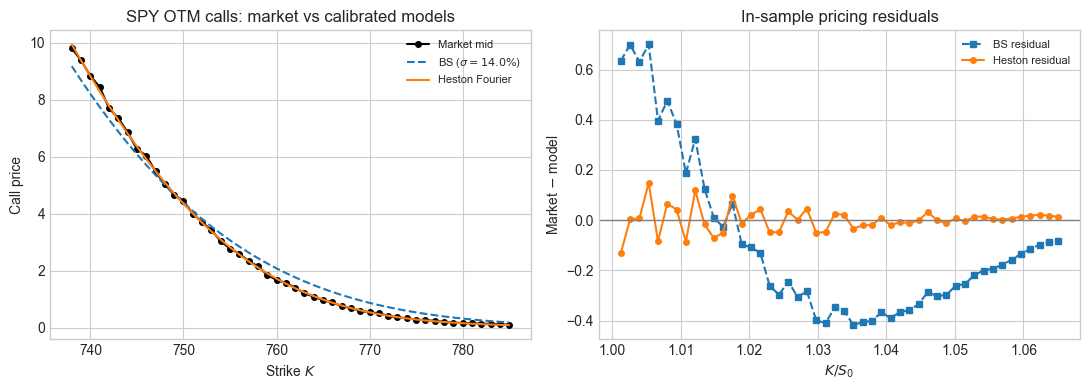

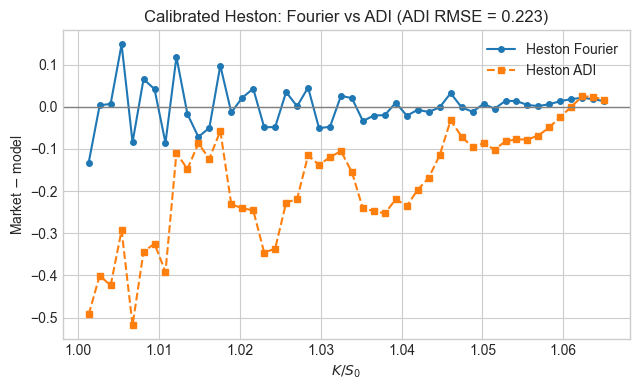

ADI RMSE vs market (calibrated params): 0.2229
Saved calibrated parameters to data\calibrated_params.json


In [94]:
moneyness = chain.strikes / chain.spot

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4))

ax_l.plot(chain.strikes, chain.mid_prices, "ko-", label="Market mid", ms=4)
ax_l.plot(chain.strikes, bs_prices, "--", label=rf"BS ($\sigma={bs_fit.sigma*100:.1f}\%$)")
ax_l.plot(chain.strikes, heston_prices, "-", label="Heston Fourier")
ax_l.set_xlabel("Strike $K$")
ax_l.set_ylabel("Call price")
ax_l.set_title("SPY OTM calls: market vs calibrated models")
ax_l.legend(fontsize=8)

ax_r.plot(moneyness, chain.mid_prices - bs_prices, "s--", label="BS residual", ms=4)
ax_r.plot(moneyness, chain.mid_prices - heston_prices, "o-", label="Heston residual", ms=4)
ax_r.axhline(0.0, color="gray", lw=1)
ax_r.set_xlabel("$K / S_0$")
ax_r.set_ylabel("Market $-$ model")
ax_r.set_title("In-sample pricing residuals")
ax_r.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "calibration_market_fit.png", dpi=150)
display(fig)
plt.close(fig)

# ADI check with calibrated parameters (single solve, K = S0 reference).
adi_params = HestonModelParams(
    r=chain.rate,
    kappa=heston_fit.kappa,
    theta=heston_fit.theta,
    xi=heston_fit.xi,
    rho=heston_fit.rho,
    K=chain.spot,
)
adi_grid = build_heston_grid(81, 41)
u_cal, adi_grid, _ = solve_heston_adi(
    adi_params, chain.maturity, grid=adi_grid, n_steps=400, rannacher_steps=10
)
adi_prices = prices_along_strikes(u_cal, adi_grid, chain.strikes, heston_fit.v0, chain.spot)
adi_rmse = float(np.sqrt(np.mean((adi_prices - chain.mid_prices) ** 2)))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(moneyness, chain.mid_prices - heston_prices, "o-", label="Heston Fourier", ms=4)
ax.plot(moneyness, chain.mid_prices - adi_prices, "s--", label="Heston ADI", ms=4)
ax.axhline(0.0, color="gray", lw=1)
ax.set_xlabel("$K / S_0$")
ax.set_ylabel("Market $-$ model")
ax.set_title(f"Calibrated Heston: Fourier vs ADI (ADI RMSE = {adi_rmse:.3f})")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "calibration_residuals.png", dpi=150)
display(fig)
plt.close(fig)

print(f"ADI RMSE vs market (calibrated params): {adi_rmse:.4f}")

params_path = save_calibrated_params(bs_fit, heston_fit)
print(f"Saved calibrated parameters to {params_path.relative_to(ROOT)}")

## 7. Convergence analysis and model comparison

We quantify the consistency of the ADI solver by measuring discrete $L^2$ and $L^\infty$ errors against the Fourier benchmark on the same $(x,v)$ grid. Spatial and temporal refinement studies yield empirical convergence orders. We also test stability when the **Feller condition** $2\kappa\theta \ge \xi^2$ is violated. Market calibration to SPY quotes is reported separately in notebook §6 / PDF Section 7. Full convergence discussion is in **Section 8** of the report.

In [95]:
import time
from scipy.optimize import minimize_scalar

from utils.convergence import (
    characteristic_mesh_size,
    empirical_orders,
    error_norms,
    feller_ratio,
    fourier_surface_on_grid,
    interior_mask,
    market_pricing_errors,
    run_adi_with_reference,
)
from utils.heston_adi_solver import (
    HestonModelParams,
    price_at_point,
    prices_along_strikes,
    solve_heston_adi,
)
from utils.black_scholes import black_scholes_call

# Baseline parameters (Sections 3 and 5).
S0 = 100.0
K = 100.0
T = 1.0
r = 0.05
v0 = 0.04
kappa = 2.0
theta = 0.04
xi = 0.3
rho = -0.7

BASE_PARAMS = HestonModelParams(r=r, kappa=kappa, theta=theta, xi=xi, rho=rho, K=K)
N_QUAD_REF = 128
RANNACHER = 10

print(f"Feller ratio 2*kappa*theta/xi^2 = {feller_ratio(kappa, theta, xi):.3f} (>= 1: satisfied)")

Feller ratio 2*kappa*theta/xi^2 = 1.778 (>= 1: satisfied)


Grid 41x21 | h=5.0000e-02 | L2=2.4689e+00 | Linf=2.0937e+01 | 13.9s
Grid 61x31 | h=3.3333e-02 | L2=1.0588e+00 | Linf=1.9851e+01 | 29.3s
Grid 81x41 | h=2.5000e-02 | L2=1.9659e+00 | Linf=2.6215e+01 | 48.2s
Empirical L2 orders (spatial):     [ 2.09 -2.15]
Empirical Linf orders (spatial):   [ 0.13 -0.97]


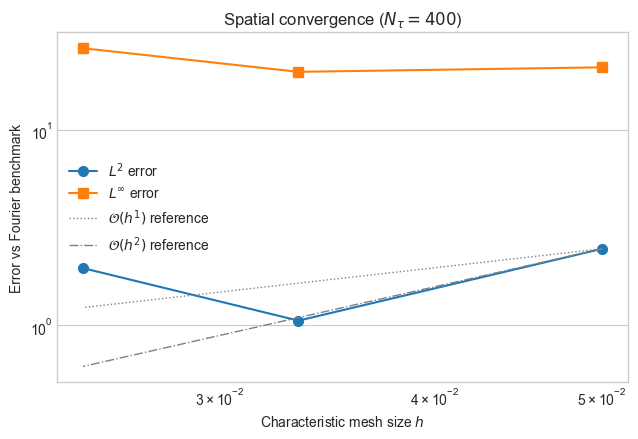

In [96]:
# --- Spatial convergence (fixed Nt = 400) ---
SPATIAL_LEVELS = [(41, 21), (61, 31), (81, 41)]
NT_SPATIAL = 400

spatial_rows = []
for nx, nv in SPATIAL_LEVELS:
    t0 = time.perf_counter()
    u_adi, u_ref, grid, norms = run_adi_with_reference(
        BASE_PARAMS,
        T,
        nx=nx,
        nv=nv,
        n_steps=NT_SPATIAL,
        rannacher_steps=RANNACHER,
        n_quad=N_QUAD_REF,
    )
    elapsed = time.perf_counter() - t0
    h = characteristic_mesh_size(grid)
    spatial_rows.append(
        {
            "nx": nx,
            "nv": nv,
            "nodes": nx * nv,
            "h": h,
            "l2": norms.l2,
            "linf": norms.linf,
            "time_s": elapsed,
            "u_min": float(u_adi.min()),
            "u_max": float(u_adi.max()),
        }
    )
    print(
        f"Grid {nx:>2}x{nv:<2} | h={h:.4e} | L2={norms.l2:.4e} | "
        f"Linf={norms.linf:.4e} | {elapsed:.1f}s"
    )

h_spatial = np.array([row["h"] for row in spatial_rows])
l2_spatial = np.array([row["l2"] for row in spatial_rows])
linf_spatial = np.array([row["linf"] for row in spatial_rows])
p_l2_spatial = empirical_orders(l2_spatial, h_spatial)
p_linf_spatial = empirical_orders(linf_spatial, h_spatial)

print(f"Empirical L2 orders (spatial):     {np.array2string(p_l2_spatial, precision=2)}")
print(f"Empirical Linf orders (spatial):   {np.array2string(p_linf_spatial, precision=2)}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(h_spatial, l2_spatial, "o-", label=r"$L^2$ error", ms=7)
ax.loglog(h_spatial, linf_spatial, "s-", label=r"$L^\infty$ error", ms=7)
for p_ref, style in [(1.0, ":"), (2.0, "-.")]:
    ax.loglog(
        h_spatial,
        l2_spatial[0] * (h_spatial / h_spatial[0]) ** p_ref,
        style,
        color="gray",
        lw=1,
        label=rf"$\mathcal{{O}}(h^{{{p_ref:g}}})$ reference",
    )
ax.set_xlabel("Characteristic mesh size $h$")
ax.set_ylabel("Error vs Fourier benchmark")
ax.set_title(f"Spatial convergence ($N_\\tau={NT_SPATIAL}$)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "convergence_spatial.png", dpi=150)
display(fig)
plt.close(fig)

Nt= 100 | dt=1.0000e-02 | L2=1.1045e+00 | Linf=2.0267e+01 | 5.4s
Nt= 200 | dt=5.0000e-03 | L2=1.0738e+00 | Linf=1.9986e+01 | 11.3s
Nt= 400 | dt=2.5000e-03 | L2=1.0588e+00 | Linf=1.9851e+01 | 22.4s
Nt= 800 | dt=1.2500e-03 | L2=1.0514e+00 | Linf=1.9784e+01 | 43.4s
Empirical L2 orders (temporal):    [0.04 0.02 0.01]
Empirical Linf orders (temporal):  [0.02 0.01 0.  ]


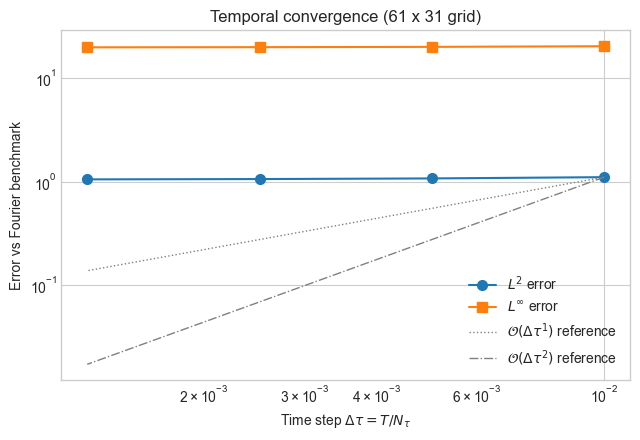

In [97]:
# --- Temporal convergence (fixed grid 61 x 31) ---
TEMPORAL_NX, TEMPORAL_NV = 61, 31
TEMPORAL_LEVELS = [100, 200, 400, 800]

temporal_grid = build_heston_grid(nx=TEMPORAL_NX, nv=TEMPORAL_NV)
u_ref_time = fourier_surface_on_grid(temporal_grid, BASE_PARAMS, T, n_quad=N_QUAD_REF)

temporal_rows = []
for nt in TEMPORAL_LEVELS:
    t0 = time.perf_counter()
    u_adi, grid, _ = solve_heston_adi(
        BASE_PARAMS,
        T,
        grid=temporal_grid,
        n_steps=nt,
        rannacher_steps=min(RANNACHER, nt // 4),
    )
    elapsed = time.perf_counter() - t0
    norms = error_norms(u_adi, u_ref_time, grid)
    dt = T / nt
    temporal_rows.append(
        {
            "nt": nt,
            "dt": dt,
            "l2": norms.l2,
            "linf": norms.linf,
            "time_s": elapsed,
        }
    )
    print(
        f"Nt={nt:>4} | dt={dt:.4e} | L2={norms.l2:.4e} | "
        f"Linf={norms.linf:.4e} | {elapsed:.1f}s"
    )

dt_time = np.array([row["dt"] for row in temporal_rows])
l2_time = np.array([row["l2"] for row in temporal_rows])
linf_time = np.array([row["linf"] for row in temporal_rows])
p_l2_time = empirical_orders(l2_time, dt_time)
p_linf_time = empirical_orders(linf_time, dt_time)

print(f"Empirical L2 orders (temporal):    {np.array2string(p_l2_time, precision=2)}")
print(f"Empirical Linf orders (temporal):  {np.array2string(p_linf_time, precision=2)}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(dt_time, l2_time, "o-", label=r"$L^2$ error", ms=7)
ax.loglog(dt_time, linf_time, "s-", label=r"$L^\infty$ error", ms=7)
for p_ref, style in [(1.0, ":"), (2.0, "-.")]:
    ax.loglog(
        dt_time,
        l2_time[0] * (dt_time / dt_time[0]) ** p_ref,
        style,
        color="gray",
        lw=1,
        label=rf"$\mathcal{{O}}(\Delta\tau^{{{p_ref:g}}})$ reference",
    )
ax.set_xlabel(r"Time step $\Delta\tau = T/N_\tau$")
ax.set_ylabel("Error vs Fourier benchmark")
ax.set_title(f"Temporal convergence ({TEMPORAL_NX} x {TEMPORAL_NV} grid)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "convergence_temporal.png", dpi=150)
display(fig)
plt.close(fig)

Feller satisfied   | ratio=1.778 | ATM ADI=10.5457 | Fourier=10.3942 | rel err=1.457e-02 | u in [-0.00, 638.91] | stable=True
Feller violated    | ratio=0.096 | ATM ADI=16.1617 | Fourier=9.6087 | rel err=6.820e-01 | u in [-267.23, 1120.61] | stable=False


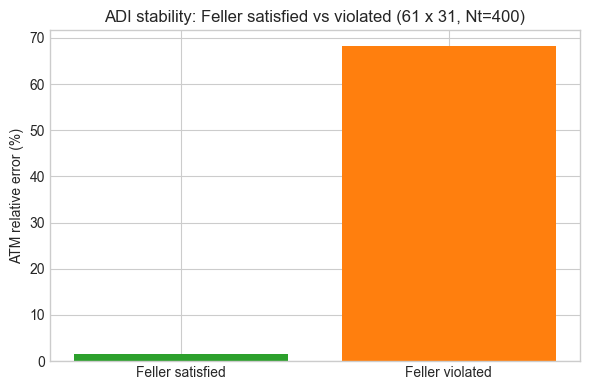

In [98]:
# --- Feller condition: satisfied vs violated ---
FELLER_CASES = [
    {
        "label": "Feller satisfied",
        "kappa": 2.0,
        "theta": 0.04,
        "xi": 0.3,
        "rho": -0.7,
    },
    {
        "label": "Feller violated",
        "kappa": 0.3,
        "theta": 0.04,
        "xi": 0.5,
        "rho": -0.7,
    },
]

feller_rows = []
for case in FELLER_CASES:
    params = HestonModelParams(
        r=r,
        kappa=case["kappa"],
        theta=case["theta"],
        xi=case["xi"],
        rho=case["rho"],
        K=K,
    )
    ratio = feller_ratio(case["kappa"], case["theta"], case["xi"])
    u_adi, grid, _ = solve_heston_adi(
        params,
        T,
        nx=61,
        nv=31,
        n_steps=400,
        rannacher_steps=RANNACHER,
    )
    fourier_atm = heston_call_price(
        S0, K, T, r, v0, case["kappa"], case["theta"], case["xi"], case["rho"]
    )
    adi_atm = price_at_point(u_adi, grid, np.log(S0 / K), v0)
    rel_err = abs(adi_atm - fourier_atm) / fourier_atm
    row = {
        "case": case["label"],
        "feller_ratio": ratio,
        "adi_atm": adi_atm,
        "fourier_atm": fourier_atm,
        "rel_err": rel_err,
        "u_min": float(u_adi.min()),
        "u_max": float(u_adi.max()),
        "stable": bool(np.isfinite(u_adi).all() and u_adi.min() > -1.0),
    }
    feller_rows.append(row)
    print(
        f"{case['label']:18s} | ratio={ratio:.3f} | ATM ADI={adi_atm:.4f} | "
        f"Fourier={fourier_atm:.4f} | rel err={rel_err:.3e} | "
        f"u in [{row['u_min']:.2f}, {row['u_max']:.2f}] | stable={row['stable']}"
    )

labels = [row["case"] for row in feller_rows]
atm_errors = [100.0 * row["rel_err"] for row in feller_rows]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, atm_errors, color=["tab:green", "tab:orange"])
ax.set_ylabel("ATM relative error (%)")
ax.set_title("ADI stability: Feller satisfied vs violated (61 x 31, Nt=400)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feller_stability.png", dpi=150)
display(fig)
plt.close(fig)

In [99]:
# Market-vs-model comparison on real SPY quotes is in notebook Section 6.
print("Market calibration (SPY snapshot) is reported in Section 6.")
print("See calibration_market_fit.png and calibration_residuals.png in figures/.")

Market calibration (SPY snapshot) is reported in Section 6.
See calibration_market_fit.png and calibration_residuals.png in figures/.


## 8. Implied volatility surfaces

Black–Scholes implies a **flat** volatility surface; equity index options exhibit a **smile/skew** across strikes and maturities. We convert call mids and model prices into Black–Scholes implied volatilities $\sigma_{\mathrm{imp}}(K,T)$ via Newton–Raphson (Section 1), then plot three-dimensional surfaces for:

1. **Market** (multi-expiry SPY snapshot, `data/spy_options_surface.csv`);
2. **Calibrated Black–Scholes** (constant $\sigma_{\mathrm{BS}}$ plane);
3. **Heston Fourier** and **Heston ADI** using the calibrated parameters from Section 6.

Theory and conclusions are in **Section 9** of the PDF report.

Surface quotes: 569 across 10 maturities
Spot S0 = 737.05, rate r = 0.0450
Maturity range: [0.036, 0.227] years
Loaded calibration: sigma_BS=0.1400, v0=0.0189, kappa=7.343, rho=-0.656


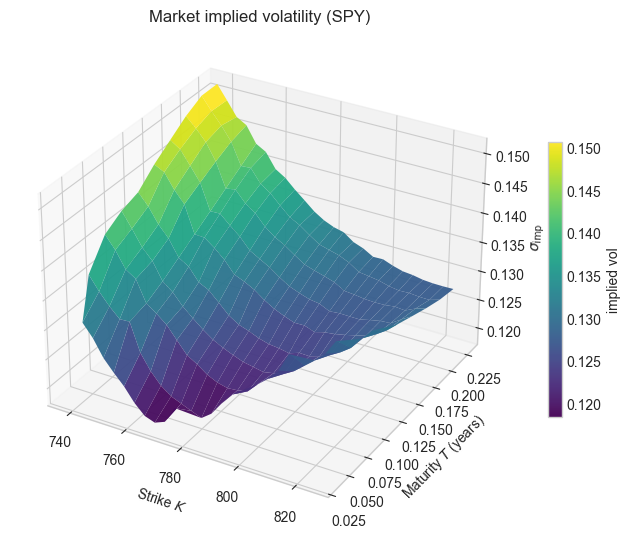

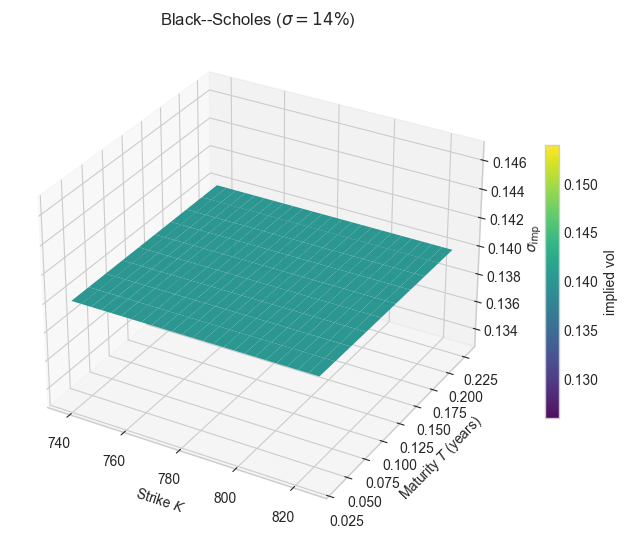

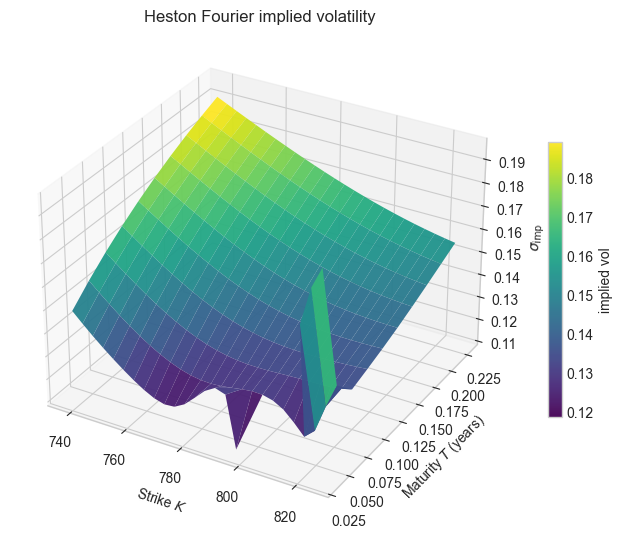

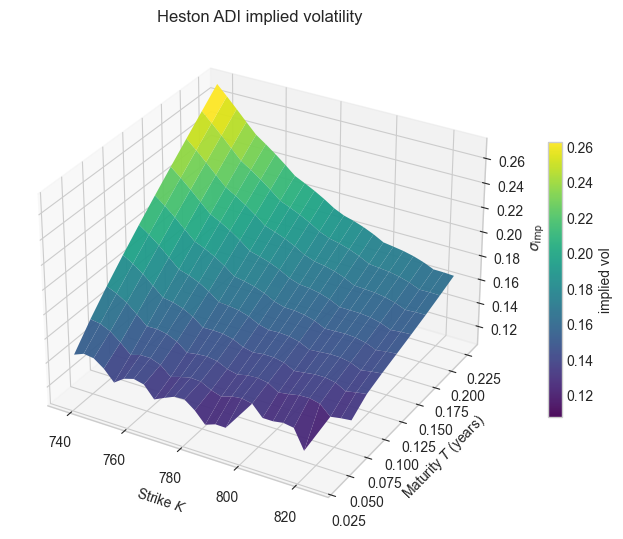

In [100]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from utils.calibrated_store import load_calibrated_params
from utils.implied_vol_surface import IVSurface, aligned_model_surfaces, market_iv_surface
from utils.market_data import load_surface_csv

surface_df = load_surface_csv()
spot = float(surface_df["spot"].iloc[0])
rate = float(surface_df["r"].iloc[0])

print(f"Surface quotes: {len(surface_df)} across {surface_df['T'].nunique()} maturities")
print(f"Spot S0 = {spot:.2f}, rate r = {rate:.4f}")
print(f"Maturity range: [{surface_df['T'].min():.3f}, {surface_df['T'].max():.3f}] years")

# Calibrated parameters from Section 6 (saved to data/calibrated_params.json).
_cal = load_calibrated_params()
SIGMA_BS = float(_cal["sigma_bs"])
HESTON_V0 = float(_cal["heston"]["v0"])
HESTON_KAPPA = float(_cal["heston"]["kappa"])
HESTON_THETA = float(_cal["heston"]["theta"])
HESTON_XI = float(_cal["heston"]["xi"])
HESTON_RHO = float(_cal["heston"]["rho"])
print(
    f"Loaded calibration: sigma_BS={SIGMA_BS:.4f}, "
    f"v0={HESTON_V0:.4f}, kappa={HESTON_KAPPA:.3f}, rho={HESTON_RHO:.3f}"
)

market_surface = market_iv_surface(surface_df, n_strikes=25, n_maturities=10)
adi_params = HestonModelParams(
    r=rate,
    kappa=HESTON_KAPPA,
    theta=HESTON_THETA,
    xi=HESTON_XI,
    rho=HESTON_RHO,
    K=spot,
)

surfaces = aligned_model_surfaces(
    market_surface,
    spot=spot,
    rate=rate,
    sigma_bs=SIGMA_BS,
    heston_params=(HESTON_V0, HESTON_KAPPA, HESTON_THETA, HESTON_XI, HESTON_RHO),
    adi_params=adi_params,
    v0=HESTON_V0,
    include_adi=True,
)


def plot_iv_surface(surface: IVSurface, title: str, filename: str) -> None:
    """Render a 3D implied-volatility surface and save to figures/."""
    kk, tt = np.meshgrid(surface.strikes, surface.maturities)
    fig = plt.figure(figsize=(8, 5.5))
    ax = fig.add_subplot(111, projection="3d")
    iv_plot = np.ma.masked_invalid(surface.iv)
    mesh = ax.plot_surface(
        kk,
        tt,
        iv_plot,
        cmap="viridis",
        linewidth=0,
        antialiased=True,
        alpha=0.95,
    )
    ax.set_xlabel("Strike $K$")
    ax.set_ylabel("Maturity $T$ (years)")
    ax.set_zlabel(r"$\sigma_{\mathrm{imp}}$")
    ax.set_title(title)
    fig.colorbar(mesh, shrink=0.55, label="implied vol")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=150)
    display(fig)
    plt.close(fig)


plot_iv_surface(surfaces["market"], "Market implied volatility (SPY)", "iv_surface_market.png")
plot_iv_surface(surfaces["black_scholes"], r"Black--Scholes ($\sigma=14\%$)", "iv_surface_black_scholes.png")
plot_iv_surface(surfaces["heston_fourier"], "Heston Fourier implied volatility", "iv_surface_heston_fourier.png")
plot_iv_surface(surfaces["heston_adi"], "Heston ADI implied volatility", "iv_surface_heston_adi.png")

Smile slice: T = 0.0849 y (31 days), 69 market quotes


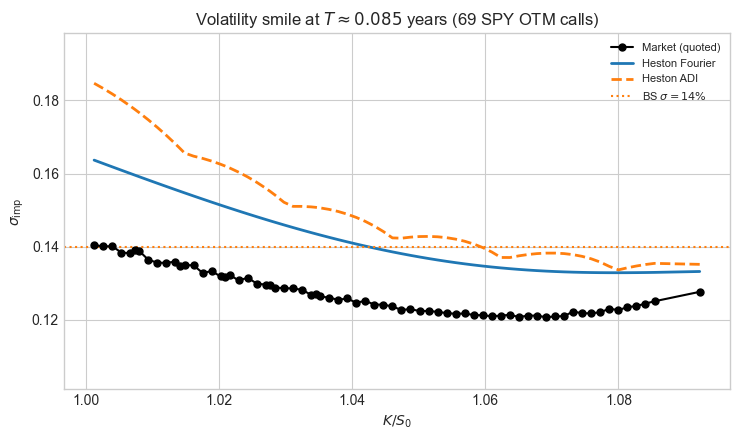

In [104]:
# 2D smile at a liquid maturity: raw market quotes + models on the same strikes.
import importlib
import utils.implied_vol_surface as _ivs_mod

_ivs_mod = importlib.reload(_ivs_mod)
market_iv_slice = _ivs_mod.market_iv_slice
model_iv_at_strikes = _ivs_mod.model_iv_at_strikes
select_slice_maturity = _ivs_mod.select_slice_maturity

T_slice = select_slice_maturity(surface_df, min_quotes=20)
slice_df = market_iv_slice(surface_df, T_slice)
strikes_slice = slice_df["strike"].to_numpy(dtype=float)
moneyness_slice = strikes_slice / spot

model_iv = model_iv_at_strikes(
    spot,
    rate,
    strikes_slice,
    T_slice,
    sigma_bs=SIGMA_BS,
    heston_params=(HESTON_V0, HESTON_KAPPA, HESTON_THETA, HESTON_XI, HESTON_RHO),
    adi_params=adi_params,
    include_adi=True,
)

print(f"Smile slice: T = {T_slice:.4f} y ({T_slice * 365:.0f} days), {len(slice_df)} market quotes")


def _plot_iv_line(ax, x, y, **kwargs):
    """Plot only finite IV points (avoids matplotlib bridging NaN gaps)."""
    mask = np.isfinite(y)
    if mask.sum() >= 2:
        ax.plot(x[mask], y[mask], **kwargs)


fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(
    moneyness_slice,
    slice_df["iv_market"],
    "ko-",
    label="Market (quoted)",
    ms=5,
    zorder=5,
)
_plot_iv_line(ax, moneyness_slice, model_iv["heston_fourier"], ls="-", label="Heston Fourier", lw=2)
_plot_iv_line(ax, moneyness_slice, model_iv["heston_adi"], ls="--", label="Heston ADI", lw=2)
ax.axhline(SIGMA_BS, color="tab:orange", ls=":", label=rf"BS $\sigma={SIGMA_BS*100:.0f}\%$")
finite_iv = np.concatenate(
    [slice_df["iv_market"].to_numpy(), model_iv["heston_fourier"], model_iv["heston_adi"]]
)
finite_iv = finite_iv[np.isfinite(finite_iv)]
if finite_iv.size:
    lo, hi = np.percentile(finite_iv, [2, 98])
    ax.set_ylim(max(0.05, lo - 0.02), hi + 0.02)
ax.set_xlabel("$K / S_0$")
ax.set_ylabel(r"$\sigma_{\mathrm{imp}}$")
ax.set_title(f"Volatility smile at $T \\approx {T_slice:.3f}$ years ({len(slice_df)} SPY OTM calls)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "iv_smile_slice.png", dpi=150)
display(fig)
plt.close(fig)